# U3_S9 - Naive Bayes: Clasificación spam
**Nombre:** Daniela Alexandra Pincay Chilán

**Dataset:** `spam.csv` (SMS Spam Collection)

**Objetivo:** A partir del ejercicio base visto en la sesión (clasificación de texto con `GaussianNB`), implementar `MultinomialNB`, interpretar las métricas obtenidas y comparar ambos modelos con gráficas de evaluación.

## 1. Importación de librerías

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

plt.rcParams['figure.dpi'] = 110

## 2. Carga y preparación de datos

In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df_nueva_data = df_nueva_data.rename(
    columns={
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df_nueva_data['categoria'].value_counts()

,count
categoria,
ham,4825
spam,747


El conjunto de datos presenta un **desbalance de clases**, donde la categoría `ham` (mensajes legítimos) es significativamente más frecuente que `spam`. Este aspecto es clave al momento de evaluar los resultados, ya que la métrica de *accuracy* puede resultar poco representativa en este contexto: un modelo que clasifique todo como `ham` podría obtener una precisión elevada, pero sin capacidad real para detectar mensajes `spam`.


## 3. División en entrenamiento y prueba

In [8]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=19, stratify=y
)
print('Entrenamiento:', X_train.shape[0], 'mensajes')
print('Prueba:', X_test.shape[0], 'mensajes')

Entrenamiento: 3900 mensajes
Prueba: 1672 mensajes


## 4. Vectorización del texto

In [9]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

print('Tamaño del vocabulario:', len(vectorizador.vocabulary_))
print('Forma de la matriz de entrenamiento:', X_train_vec.shape)

Tamaño del vocabulario: 7161
Forma de la matriz de entrenamiento: (3900, 7161)


## 5. Modelo base: GaussianNB

GaussianNB es el modelo originalmente propuesto en la sesión. Este algoritmo parte del supuesto de que todas las variables siguen una distribución normal continua, lo cual no encaja del todo bien con datos de conteo de palabras, que suelen ser dispersos, discretos y con muchos ceros. Aun así, se mantiene en el análisis como referencia para poder compararlo con otros modelos más adecuados.

In [10]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)
y_pred_gnb = gaussian.predict(X_test_vec.toarray())
y_proba_gnb = gaussian.predict_proba(X_test_vec.toarray())
print(y_pred_gnb[:20])

['spam' 'spam' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [11]:
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb, pos_label='spam')
recall_gnb = recall_score(y_test, y_pred_gnb, pos_label='spam')
precision_gnb = precision_score(y_test, y_pred_gnb, pos_label='spam')

print(f'Accuracy:  {accuracy_gnb:.4f}')
print(f'Precision: {precision_gnb:.4f}')
print(f'Recall:    {recall_gnb:.4f}')
print(f'F1-score:  {f1_gnb:.4f}')

Accuracy:  0.9127
Precision: 0.6189
Recall:    0.9062
F1-score:  0.7355


In [12]:
report_gnb = classification_report(y_test, y_pred_gnb, target_names=['ham', 'spam'])
print(report_gnb)

              precision    recall  f1-score   support

         ham       0.98      0.91      0.95      1448
        spam       0.62      0.91      0.74       224

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.94      0.91      0.92      1672



## 6. Modelo propuesto: MultinomialNB

`MultinomialNB` es un modelo especialmente adecuado para datos basados en **frecuencias de ocurrencia**, como los generados por `CountVectorizer` en procesamiento de texto. Su funcionamiento se basa en una distribución multinomial, que estima la probabilidad de aparición de cada término dentro de cada clase. Por esta razón, se ajusta de manera natural a representaciones tipo bolsa de palabras (*bag-of-words*), donde cada documento se representa como un conteo de palabras. Es un enfoque ampliamente utilizado en clasificación de texto, especialmente en problemas como la detección de spam.


In [13]:
multinomial = MultinomialNB()
multinomial.fit(X_train_vec, y_train)
y_pred_mnb = multinomial.predict(X_test_vec)
y_proba_mnb = multinomial.predict_proba(X_test_vec)
print(y_pred_mnb[:20])

['spam' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam']


In [14]:
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb, pos_label='spam')
recall_mnb = recall_score(y_test, y_pred_mnb, pos_label='spam')
precision_mnb = precision_score(y_test, y_pred_mnb, pos_label='spam')

print(f'Accuracy:  {accuracy_mnb:.4f}')
print(f'Precision: {precision_mnb:.4f}')
print(f'Recall:    {recall_mnb:.4f}')
print(f'F1-score:  {f1_mnb:.4f}')

Accuracy:  0.9868
Precision: 0.9720
Recall:    0.9286
F1-score:  0.9498


In [15]:
report_mnb = classification_report(y_test, y_pred_mnb, target_names=['ham', 'spam'])
print(report_mnb)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       0.97      0.93      0.95       224

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



## 7. Comparación de métricas: GaussianNB vs. MultinomialNB

In [16]:
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-score (spam)'],
    'GaussianNB': [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb],
    'MultinomialNB': [accuracy_mnb, precision_mnb, recall_mnb, f1_mnb]
})
comparacion['Diferencia (MNB - GNB)'] = comparacion['MultinomialNB'] - comparacion['GaussianNB']
comparacion

,Métrica,GaussianNB,MultinomialNB,Diferencia (MNB - GNB)
0,Accuracy,0.912679,0.986842,0.074163
1,Precision (spam),0.618902,0.971963,0.353060
2,Recall (spam),0.906250,0.928571,0.022321
3,F1-score (spam),0.735507,0.949772,0.214264


## 8. Matrices de confusión

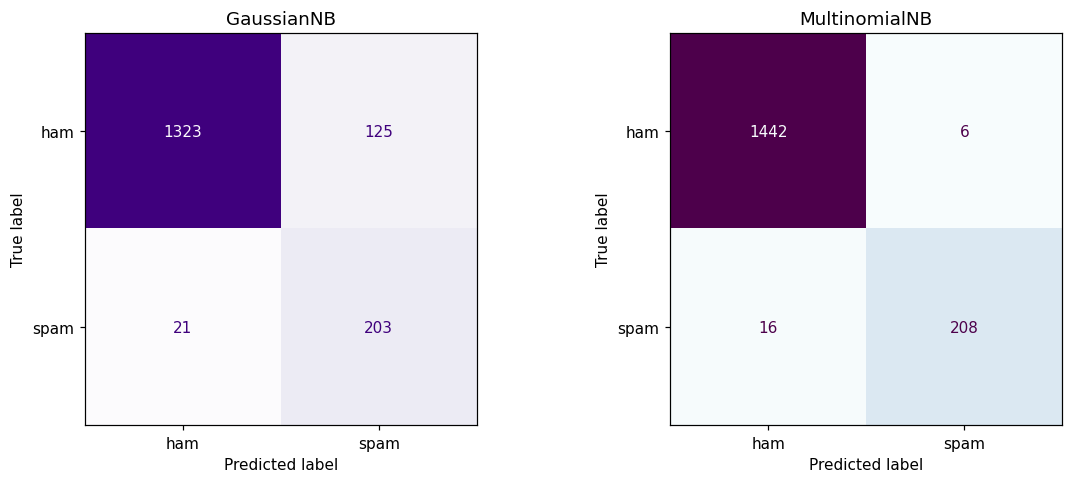

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ['ham', 'spam']

cm_gnb = confusion_matrix(y_test, y_pred_gnb, labels=labels)
disp_gnb = ConfusionMatrixDisplay(cm_gnb, display_labels=labels)
disp_gnb.plot(ax=axes[0], cmap='Purples', colorbar=False)
axes[0].set_title('GaussianNB')

cm_mnb = confusion_matrix(y_test, y_pred_mnb, labels=labels)
disp_mnb = ConfusionMatrixDisplay(cm_mnb, display_labels=labels)
disp_mnb.plot(ax=axes[1], cmap='BuPu', colorbar=False)
axes[1].set_title('MultinomialNB')

plt.tight_layout()
plt.show()

## 9. Curvas ROC

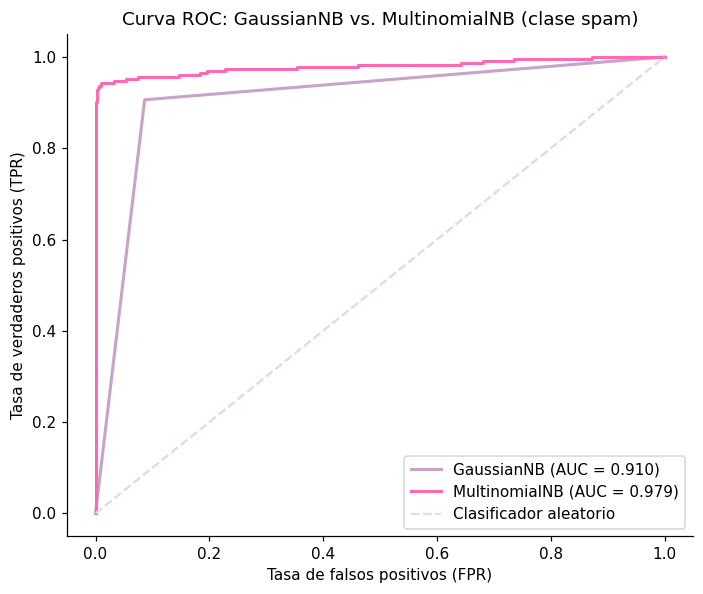

In [24]:
y_test_bin = (y_test == 'spam').astype(int)

idx_spam_gnb = list(gaussian.classes_).index('spam')
idx_spam_mnb = list(multinomial.classes_).index('spam')

fpr_gnb, tpr_gnb, _ = roc_curve(y_test_bin, y_proba_gnb[:, idx_spam_gnb])
fpr_mnb, tpr_mnb, _ = roc_curve(y_test_bin, y_proba_mnb[:, idx_spam_mnb])

auc_gnb = auc(fpr_gnb, tpr_gnb)
auc_mnb = auc(fpr_mnb, tpr_mnb)

fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.plot(
    fpr_gnb,
    tpr_gnb,
    color='#C8A2C8',
    linewidth=2,
    label=f'GaussianNB (AUC = {auc_gnb:.3f})'
)

ax.plot(
    fpr_mnb,
    tpr_mnb,
    color='#FF69B4',
    linewidth=2,
    label=f'MultinomialNB (AUC = {auc_mnb:.3f})'
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='#E6D6E6',
    label='Clasificador aleatorio'
)

ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curva ROC: GaussianNB vs. MultinomialNB (clase spam)')
ax.legend(loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**10. Interpretación de resultados**

**Sobre el desbalance de clases**

El dataset presenta aproximadamente un 87% de mensajes ham y un 13% de spam. En este contexto, la métrica de accuracy puede resultar engañosa, ya que un modelo que clasifique todos los mensajes como ham alcanzaría una precisión cercana al 87% sin identificar ningún caso de spam. Por ello, resulta más relevante analizar métricas como precision, recall y F1-score, enfocadas específicamente en la clase spam, que es el objetivo principal en un sistema de filtrado.

**¿Por qué MultinomialNB es más adecuado que GaussianNB en este caso?**

1. CountVectorizer genera una
representación basada en frecuencias de palabras, es decir, valores enteros no negativos donde predominan los ceros. Este tipo de datos se ajusta directamente al supuesto de MultinomialNB, el cual modela la distribución de ocurrencias de términos dentro de cada clase mediante un enfoque multinomial.
2. En contraste, GaussianNB asume que cada característica sigue una distribución normal continua, lo cual no es coherente con datos de conteo. En este caso, la alta presencia de ceros y la naturaleza discreta de las variables violan dicho supuesto, afectando la estimación de probabilidades.
3. La matriz de confusión permite analizar el tipo de errores cometidos por cada modelo, especialmente la diferencia entre falsos negativos (spam clasificado como ham) y falsos positivos (ham clasificado como spam). En aplicaciones reales, los falsos positivos pueden ser especialmente problemáticos, ya que implican bloquear mensajes legítimos.
4. La curva ROC y el AUC resumen el rendimiento del modelo en distintos umbrales de decisión, lo que permite evaluar su capacidad de discriminación de manera más robusta e independiente del umbral seleccionado.

**Conclusión:** en problemas de clasificación de texto basados en bolsa de palabras (bag-of-words), MultinomialNB es el enfoque más apropiado tanto teóricamente como en la práctica, ya que se adapta mejor a la naturaleza discreta y esparsa de los datos, lo que se refleja en un mejor desempeño general frente a GaussianNB.